# PoreML in fifteen minutes

The whole workflow of the benchmark on two trajectories:

1. **data** — check for the two demo trajectories, download them if they are missing (2.9 GB);
2. **train** — a small 3-D UNet that maps one frame of a drainage simulation to the next;
3. **push-forward fine-tune** — teach the model to correct its own rollout errors;
4. **inference** — roll both models out for 64 steps on a rock they have never seen, timed and scored at every step;
5. **visualise** — truth against prediction, and the error as the rollout proceeds.

Everything here is a call into the `poreml` package; each section ends with the command-line
equivalent. Setup: `uv sync --group demo`, then `uv run jupyter lab demo/demo.ipynb`. A GPU is
strongly recommended — the whole notebook takes about twenty minutes on one, and hours without.
Both trainings are skipped if a finished run is already there, so re-running it is quick.

In [1]:
import csv, json, os
from pathlib import Path

# The configs name their paths from the repository root, so work from there.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import torch

from poreml.config import Config

cfg = Config.from_yaml("demo/config.yaml")
DATA_ROOT = Path(os.environ.get("POREML_DEMO_DATA", cfg.data.root))   # where the dataset lives
cfg = cfg.updated(data={"root": str(DATA_ROOT)})
RETRAIN = False                                                        # True: train again even when a finished run exists

print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu (slow: consider train.max_batches)")

device: NVIDIA H200


## 1 · Data

The dataset lives on HuggingFace ([`PoreML/PoreML_data`](https://huggingface.co/datasets/PoreML/PoreML_data),
560 lattice-Boltzmann runs, 3.3 TB). The demo needs two of them, named in `demo/split.yaml`: drainage
through two different Bentheimer sandstone samples at 128³ with the same fluid pair. The model trains
on one rock and is tested on the other.

`poreml.download` shows what a selection costs and asks before fetching anything; files that are
already on disk are skipped, so this cell is instant the second time.

In [2]:
from poreml import download as dl
from poreml.data import load_split

split = load_split(cfg.data.split)
TRAIN_RUN, TEST_RUN = split["train"][0], split["val"][0]


def ask(prompt: str) -> bool:
    if os.environ.get("POREML_DEMO_YES") == "1":      # headless runs: agree in advance
        return True
    return input(f"{prompt} [y/N] ").strip().lower() in ("y", "yes")


state = dl.download(DATA_ROOT, runs=[TRAIN_RUN, TEST_RUN], confirm=ask)["state"]
assert state in ("present", "downloaded"), "the demo needs its two trajectories"

dataset   https://huggingface.co/datasets/PoreML/PoreML_data
          560 runs, 3952 files, 3.32 TB in full
into      data/case

campaign      runs   files        size
drainage         2      12      2.9 GB
total            2      12      2.9 GB

to fetch  0 file(s), 0 B (2.9 GB already on disk)
free      112.35 TB on the target filesystem


> **CLI** `uv run poreml download --split demo/split.yaml` — or `--campaign drainage --size 128`
> for a whole slice of the benchmark, or no filter at all for everything.

### What a trajectory holds

One HDF5 per run: the rock (`1` = solid) and, every 5 000 solver steps, the phase field `phi`
(`> 0` the invading non-wetting fluid, `< 0` the wetting one), the pressure `p` and the velocity `u`.
The flow axis is the last one; the domain is `[inlet reservoir | rock | porous plate | outlet buffer]`
and only the **rock** span is scored.

drain_bent128_0055_128_M0.1_th130_b99: 204 frames of (128, 128, 161), rock span 7:135, M = 0.1, theta = 130.0
porosity 21.2% overall, 30.9% on slice 113 of 128


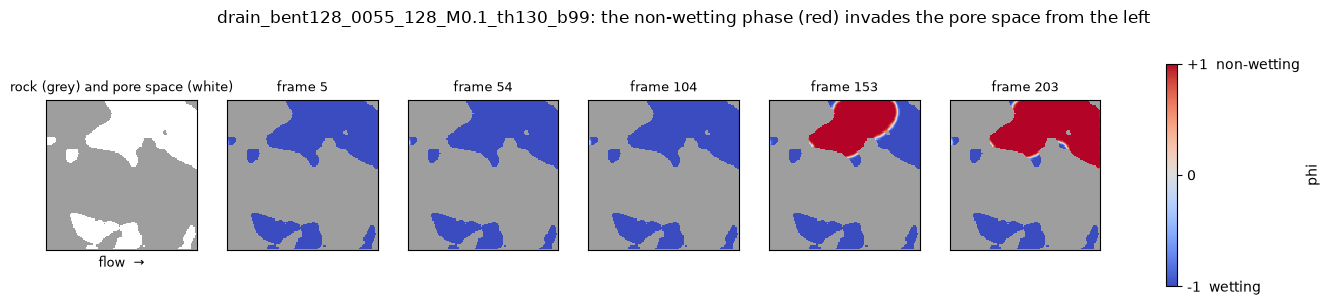

In [3]:
from matplotlib.colors import ListedColormap

from poreml.data import Trajectory, discover

refs = discover(DATA_ROOT, cfg.data.campaign)
ref = refs[TRAIN_RUN]
traj = Trajectory(ref.h5_path)
lo, hi = ref.regions["rock"]                 # the rock span of the domain; the rest is boundary device
print(f"{ref.run_id}: {len(traj.steps)} frames of {ref.shape}, rock span {lo}:{hi}, "
      f"M = {ref.params['M']}, theta = {ref.params['theta']}")

# phi runs from -1 (wetting) to +1 (non-wetting); the rock is not fluid at all, so it is masked
# out of the colour map and drawn grey. 21 % of this sample is pore space, so most of a slice IS rock.
ROCK_GREY = "0.62"
PHASE = plt.get_cmap("coolwarm").copy()
PHASE.set_bad(ROCK_GREY)                     # solid: masked out of the phase map entirely
GEOMETRY = ListedColormap(["white", ROCK_GREY])


def show(ax, phi, solid, title):
    # One slice across the flow: invading phase red, wetting phase blue, rock grey.
    im = ax.imshow(np.ma.masked_where(solid, phi), cmap=PHASE, vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im


def liveliest_slice(phi_first, phi_last, pore):
    # The slice where the most pore voxels change phase between the first and last frame shown.
    # That favours both open pore space and visible motion, which an arbitrary slice does not:
    # the rock is 79 % of this sample, and the mid-plane happens to be nearly static.
    changed = ((phi_first > 0) != (phi_last > 0)) & pore
    return int(changed.sum(axis=(1, 2)).argmax())


rock = traj.rock[:, :, lo:hi] == 1
picks = np.linspace(5, len(traj.steps) - 1, 5).astype(int)
SLICE = liveliest_slice(traj.frame(traj.steps[picks[0]], "phi")[:, :, lo:hi],
                        traj.frame(traj.steps[picks[-1]], "phi")[:, :, lo:hi], ~rock)
solid = rock[SLICE]
print(f"porosity {1 - rock.mean():.1%} overall, {1 - solid.mean():.1%} on slice {SLICE} of {rock.shape[0]}")
fig, axes = plt.subplots(1, 6, figsize=(17, 3.4))
axes[0].imshow(solid.astype(int), cmap=GEOMETRY, vmin=0, vmax=1, interpolation="nearest")   # the geometry alone
axes[0].set_title("rock (grey) and pore space (white)", fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, t in zip(axes[1:], picks):
    im = show(ax, traj.frame(traj.steps[t], "phi")[SLICE, :, lo:hi], solid, f"frame {t}")
bar = fig.colorbar(im, ax=axes, shrink=0.85, ticks=[-1, 0, 1])
bar.ax.set_yticklabels(["-1  wetting", "0", "+1  non-wetting"])
bar.set_label("phi")
axes[0].set_xlabel("flow  →", fontsize=9)
fig.suptitle(f"{TRAIN_RUN}: the non-wetting phase (red) invades the pore space from the left")
plt.show()

## 2 · Train

`demo/config.yaml` is the benchmark's UNet recipe shrunk to run in minutes: one training
trajectory instead of 128 and 1 M parameters instead of 11 M. It predicts the same five fields
the benchmark does — `phi`, the three velocity components and `p` — from one past frame. A config fully determines a run — data, task, model, optimiser, metrics, rollout protocol —
and is copied into the run directory.

After every epoch the validation trajectory is also **rolled out** for 64 steps: the model is fed
its own predictions. One-step error and rollout error are different things (watch them disagree
below), so when training ends the epoch with the best *rollout* is kept as `ckpts/best_rollout.pt`.

In [4]:
from poreml.train import train


def newest_finished(name: str) -> Path | None:
    runs = [d for d in sorted(Path(cfg.out_dir).glob(f"{name}_*")) if (d / "run_meta.json").is_file()]
    runs = [d for d in runs if json.loads((d / "run_meta.json").read_text()).get("status") == "finished"]
    return runs[-1] if runs else None


base_dir = (None if RETRAIN else newest_finished(cfg.name)) or train(cfg)
print("run directory:", base_dir)

run directory: demo/runs/demo_base_20260920-165920


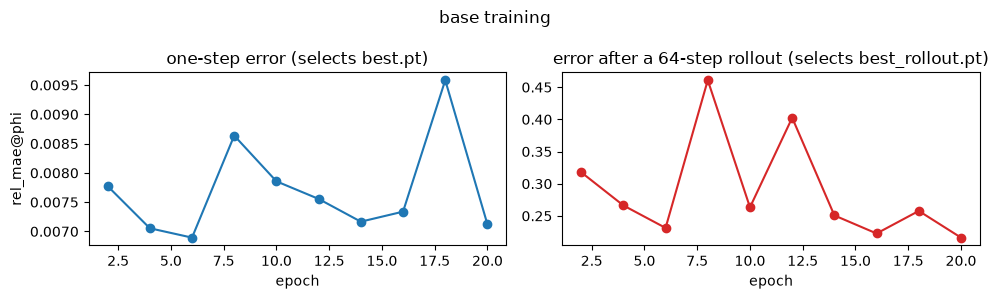

best_rollout.pt = epoch 20


In [5]:
%matplotlib inline
# (training draws its own figures with a file backend; this switches back to the notebook's)


def read_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))


def plot_training(run_dir, title):
    rows = read_csv(Path(run_dir) / "eval" / "metrics.csv")
    epochs = [int(r["epoch"]) + 1 for r in rows]
    fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3))
    a.plot(epochs, [float(r["rel_mae@phi"]) for r in rows], "o-")
    a.set(title="one-step error (selects best.pt)", xlabel="epoch", ylabel="rel_mae@phi")
    b.plot(epochs, [float(r["rollout/rel_mae@phi"]) for r in rows], "o-", color="C3")
    b.set(title="error after a 64-step rollout (selects best_rollout.pt)", xlabel="epoch")
    fig.suptitle(title); fig.tight_layout(); plt.show()


plot_training(base_dir, "base training")
chosen = json.loads((base_dir / "run_meta.json").read_text())["progress"]["best_rollout"]
print(f"best_rollout.pt = epoch {chosen['epoch'] + 1}")

> **CLI** `uv run poreml train -c demo/config.yaml` (`--resume auto` continues a run that was
> interrupted). The run directory holds `config.yaml`, `run_meta.json`, `metrics.csv`, `ckpts/`,
> the periodic rollouts under `eval/` and the full evaluation of the selected checkpoint under `final/`.

## 3 · Push-forward fine-tune

A model trained one step at a time only ever sees true frames as input; in a rollout it sees its
own slightly wrong ones, and the errors compound. The **push-forward trick** (Brandstetter et al.
2022) closes that gap: on a *pushed* batch the model first steps on its own output without
gradients, then takes one graded step against the true frame further ahead — it is trained on the
inputs it will meet in a rollout. The other batches get a little Gaussian noise on their inputs.

In the benchmark this is a second phase (`case/train_push/`): every finished training is fine-tuned
from its best checkpoint at a third of the learning rate. The same here, as an edit of the config:

In [6]:
push_cfg = cfg.updated(
    name="demo_push",
    train={
        "init_from": str(base_dir / "ckpts" / "best_rollout.pt"),   # start from the base model's weights
        "epochs": 10,                                              # half the base run, the benchmark's ratio
        "lr": cfg.train.lr / 3,
        "push_forward": {"steps": 2, "prob_start": 0.5, "prob_end": 1.0, "noise": 0.01},
    },
)
push_dir = (None if RETRAIN else newest_finished(push_cfg.name)) or train(push_cfg)
print("run directory:", push_dir)

run directory: demo/runs/demo_push_20260920-170748


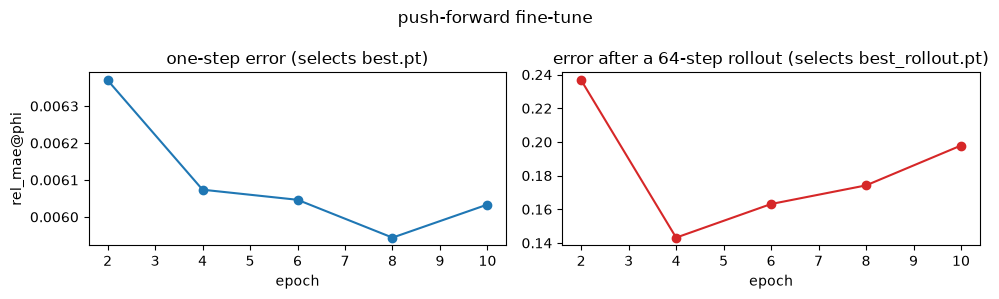

In [7]:
%matplotlib inline
plot_training(push_dir, "push-forward fine-tune")

> **CLI** the same two keys, `train.init_from` and `train.push_forward`, in a YAML file;
> `case/train_push/make_configs.py` derives the benchmark's fine-tune configs this way.

## 4 · Inference

`rollout_inference` is the benchmark's test protocol: every full 64-step window of every run of
the split, starting every 64 frames from frame 0. The model sees **one true frame** and then runs
on its own output for 64 steps; every step is scored and timed, and a few predicted frames per
window are stored for the figures. The test trajectory has 215 frames, hence three windows.

In [8]:
from poreml.inference import rollout_inference

runs = {"base": base_dir, "push-forward": push_dir}
results = {}
for label, run_dir in runs.items():
    results[label] = rollout_inference(cfg, ckpt=run_dir / "ckpts" / "best_rollout.pt", split="val")
    r = results[label]
    print(f"{label:>13}: {r['n_windows']} windows, forward {r['timing']['forward_s']['median'] * 1e3:.0f} ms/step, "
          f"rel_mae@phi after {r['protocol']['horizon']} steps = {r['at_horizon']['rel_mae@phi']:.3f}")

         base: 3 windows, forward 29 ms/step, rel_mae@phi after 64 steps = 0.453
 push-forward: 3 windows, forward 29 ms/step, rel_mae@phi after 64 steps = 0.228


> **CLI** `uv run poreml inference -c <run_dir>/config.yaml --ckpt <run_dir>/ckpts/best_rollout.pt`,
> then `uv run poreml metric -c ... --ckpt ...` scores the stored frames with the config's whole
> metric list on CPU (in the benchmark that list includes interface curvature and the Minkowski
> functionals, which need meshing). `<run_dir>/inference.csv` is the raw record: one row per
> window and step.

## 5 · Visualise

The error of an autonomous rollout grows with the horizon; that curve, not the one-step error,
is what the benchmark compares models on.

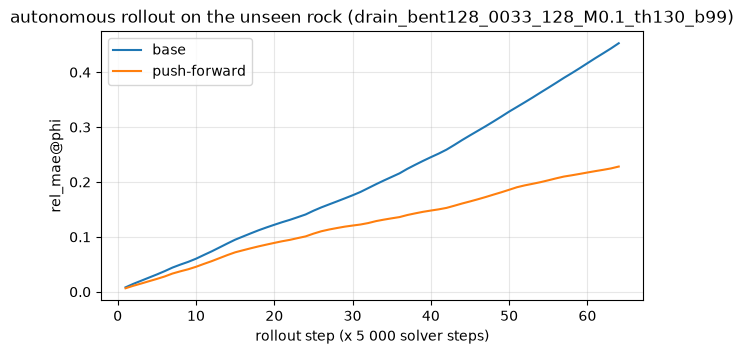

In [9]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, r in results.items():
    ax.plot(r["scored_steps"], r["summary"]["rel_mae@phi"], label=label)
ax.set(xlabel="rollout step (x 5 000 solver steps)", ylabel="rel_mae@phi", title=f"autonomous rollout on the unseen rock ({TEST_RUN})")
ax.legend(); ax.grid(alpha=0.3); plt.show()

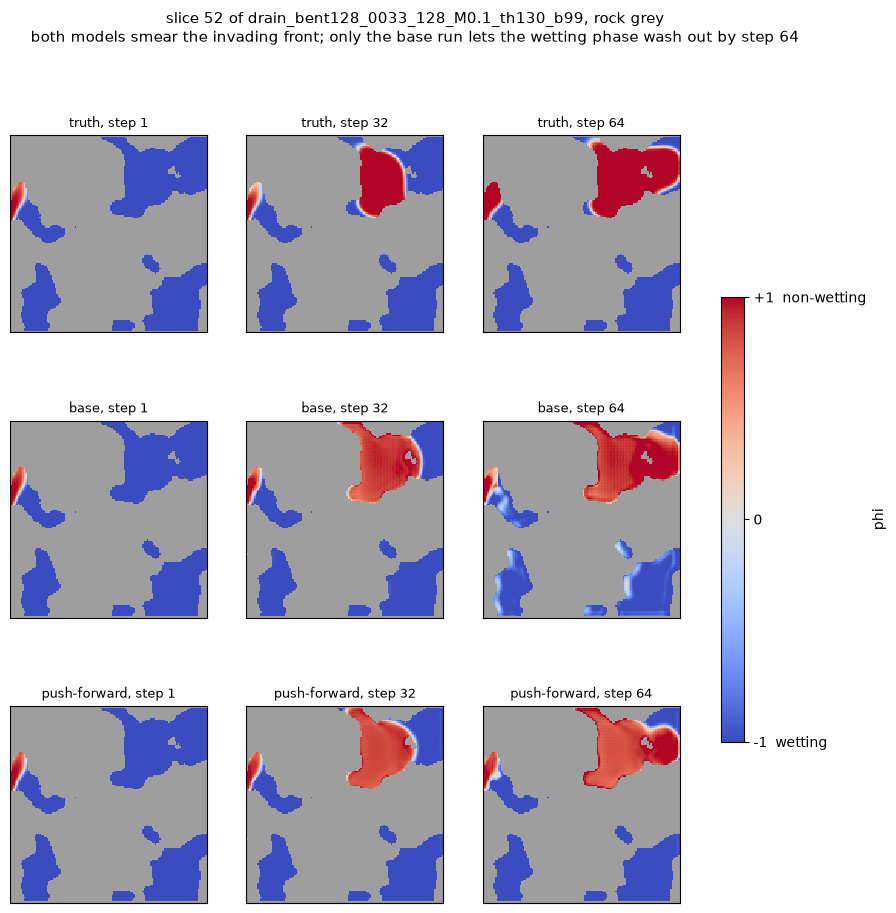

In [10]:
from poreml.frames import H5FrameStore

stores = {label: H5FrameStore(run_dir / "inference" / "frames") for label, run_dir in runs.items()}

# Which window to look at. The three stored windows start at frames 0, 64 and 128; this is the
# middle one. The first is still mostly pre-invasion, and in the last both models miss a pore
# that fills entirely — a harsher picture than their rel_mae above. Change T0 to see either.
T0 = stores["base"].windows(TEST_RUN)[1]
steps = stores["base"].steps(TEST_RUN, T0)
steps = [steps[0], steps[len(steps) // 2], steps[-1]]

test_ref = refs[TEST_RUN]
test_traj = Trajectory(test_ref.h5_path)
lo, hi = test_ref.regions["rock"]
test_rock = test_traj.rock[:, :, lo:hi] == 1
# its own slice, chosen over the frames this figure shows — not the one the data figure used,
# and not one chosen on the whole run, which can be static over this particular window.
TEST_SLICE = liveliest_slice(test_traj.frame(test_traj.steps[T0 + steps[0]], "phi")[:, :, lo:hi],
                             test_traj.frame(test_traj.steps[T0 + steps[-1]], "phi")[:, :, lo:hi], ~test_rock)
test_solid = test_rock[TEST_SLICE]

fig, axes = plt.subplots(3, len(steps), figsize=(3.6 * len(steps), 10.5))
for j, h in enumerate(steps):
    show(axes[0, j], test_traj.frame(test_traj.steps[T0 + h], "phi")[TEST_SLICE, :, lo:hi], test_solid, f"truth, step {h}")
    for i, (label, store) in enumerate(stores.items(), start=1):
        im = show(axes[i, j], store.read(TEST_RUN, T0, h)[0, TEST_SLICE], test_solid, f"{label}, step {h}")
bar = fig.colorbar(im, ax=axes, shrink=0.55, ticks=[-1, 0, 1])
bar.ax.set_yticklabels(["-1  wetting", "0", "+1  non-wetting"])
bar.set_label("phi")
fig.suptitle(f"slice {TEST_SLICE} of {TEST_RUN}, rock grey\n"
             "both models smear the invading front; only the base run lets the wetting phase wash out by step 64",
             fontsize=11)
plt.show()

Both models blur the sharp interface the solver resolves — a one-step model has no reason to keep
it sharp. The difference is what happens to the rest of the field: by step 64 the base run has let
the wetting phase (deep blue) drift towards zero, while the push-forward run, which was trained on
its own predictions, still holds it. That is the gap in the curve above.

> **CLI** `uv run poreml render -c <config> --ckpt <ckpt> --run <run_id> --out-dir <dir>` renders the
> same comparison in 3-D as a GIF (`uv sync --group viz`).

## Where next

- **The benchmark**: `configs/<campaign>/<model>_<kind>.yaml` are the training configs (five
  models, four campaigns), `case/train/` and `case/train_push/` run them as SLURM arrays,
  `case/shift/` and `case/scale/` are the transfer studies (unseen rock types, 8x larger domains).
- **Your model**: one file under `src/poreml/models/` with `@MODELS.register("name")`, plus a
  config — every stage above then works unchanged. `uv run poreml ls models|tasks|metrics` lists
  what is registered.
- **More data**: `uv run poreml download --help`.